# DJ circuit slowly building up. 

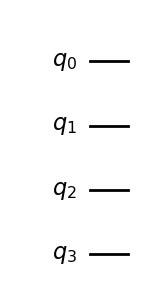

In [157]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import aer_simulator
import numpy as np 
n =3 
f0allx = QuantumCircuit(n+1) # constant oracle for f(x) = 0 for all x
# so nothing will happen to the qubits 
f0allx.draw('mpl')





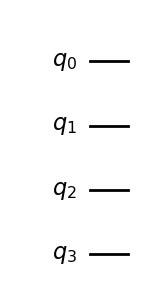

In [158]:
n=3 
f1allx = QuantumCircuit(n+1) # constant oracle for f(x) = 1 for all x
# that means we should get - at the output for all qubits. 
# f1allx.x(n)
f1allx.draw('mpl')



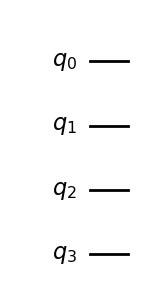

In [ ]:
n=3
f01half = QuantumCircuit (n+1) # balanced oracle for f(x) = 0 for half of the inputs and f(x) = 1 for the other half
# we will use the CNOT gate to implement this.
xgates = "000"
cxgates = "111"
# Apparently it does not depend on the xgates because it undoes it before the oracle circuit ends. 
# Changing cxgats decides whether it is balanced or constant.
# Alternate bits make it balanced otherwise constant.

# Place X-gates before implenting CX in the next loop 
for i in range(n): 
    if xgates[i] == "1":
        f01half.x(i)

# place CX-gates to give phase at desired combinations
for m in range(n): 
    if cxgates[m] == "1": 
        f01half.cx(m,n)

# place X-gates after implementing CX in the previous loop
for k in range(n): 
    if xgates[k] == "1": 
        f01half.x(k)    

f1allx.draw('mpl')

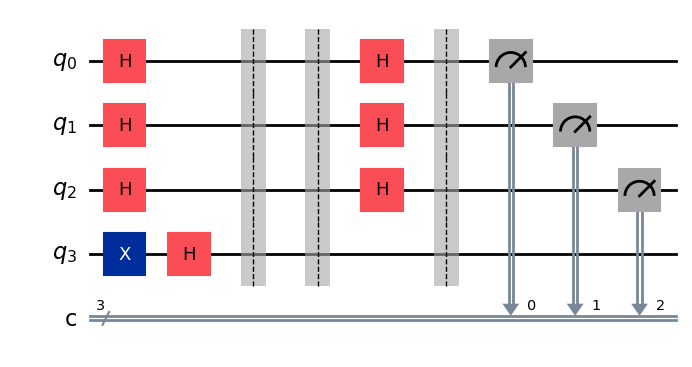

In [160]:
dj_circuit = QuantumCircuit(n+1, n)



# CHOOSE ORACLE HERE 
oracle = f1allx



# Apply H-gates
for qubit in range(n):
    dj_circuit.h(qubit)

#put ancilla qubit in state | - > 
dj_circuit.x(n) 
dj_circuit.h(n)

dj_circuit.barrier() 

# Add oracle 

dj_circuit = dj_circuit.compose(oracle)
dj_circuit.barrier()


# Repeat H gates 
for qubit in range(n):
    dj_circuit.h(qubit)
dj_circuit.barrier() 


# Measure 
for i in range(n):
    dj_circuit.measure(i,i)
display(dj_circuit.draw('mpl'))


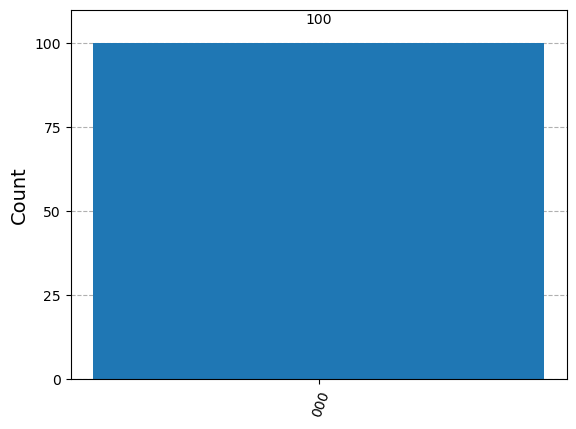

In [161]:
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit_ibm_runtime import SamplerV2
from qiskit.visualization import plot_histogram

# Import the AerSimulator
from qiskit_aer import AerSimulator

# Initialize the AerSimulator
aer_simulator  = AerSimulator()
sampler_aer = SamplerV2(mode = aer_simulator)
# Transpile the circuit for the AerSimulator
transpiled_circuit = transpile(dj_circuit, backend= aer_simulator)

# Run the circuit on the AerSimulator
job_aer = sampler_aer.run([(transpiled_circuit, None, 100), (transpiled_circuit, None, 100)])

# Get the measurement counts
results_aer = job_aer.result()
counts_100 = results_aer[0].data.c.get_counts()
# Plot the histogram
plot_histogram(counts_100)

# We get 101 at the output which means the function is balanced.. because it's something other than 0 state 
# changing the oracle to constant get us 000 at the output.
# changing the oracle to balanced get us 101 at the output.